In [41]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

data_path = "../outputs/%s/embeddings/"


In [42]:
test_proj = np.load(data_path%'run_testsupmodes' + "test_projections.npy")
test_labels = np.load(data_path%'run_testsupmodes' + "test_labels.npy")

print("test_proj shape:", test_proj.shape)
print("test_labels shape:", test_labels.shape)

test_proj shape: (1142, 256)
test_labels shape: (1142, 20)


In [43]:
# Mask for FRI only, FRII only, and hybrid
mask_fri = (test_labels[:,0] == 1) & (test_labels[:,1] == 0) & (test_labels[:,2] == 0)
mask_frii = (test_labels[:,0] == 0) & (test_labels[:,1] == 1) & (test_labels[:,2] == 0)
mask_hybrid = test_labels[:, 2] == 1 #OK

# Combine them
combined_mask = mask_fri | mask_frii | mask_hybrid
print(mask_fri.shape, combined_mask.shape)

(1142,) (1142,)


In [44]:
#the labels are in the format of a one-hot encoding, so we need to convert them to a single label for each class
test_labels_single = np.argmax(test_labels[combined_mask], axis=1)

silhouette = silhouette_score(test_proj[combined_mask], test_labels_single)
print("Silhouette Score:", silhouette)

davies_bouldin = davies_bouldin_score(test_proj[combined_mask], test_labels_single)
print("Davies-Bouldin Score:", davies_bouldin)

calinski_harabasz = calinski_harabasz_score(test_proj[combined_mask], test_labels_single)
print("Calinski-Harabasz Score:", calinski_harabasz)

Silhouette Score: 0.09942561
Davies-Bouldin Score: 2.7913004887434316
Calinski-Harabasz Score: 73.34989448502759


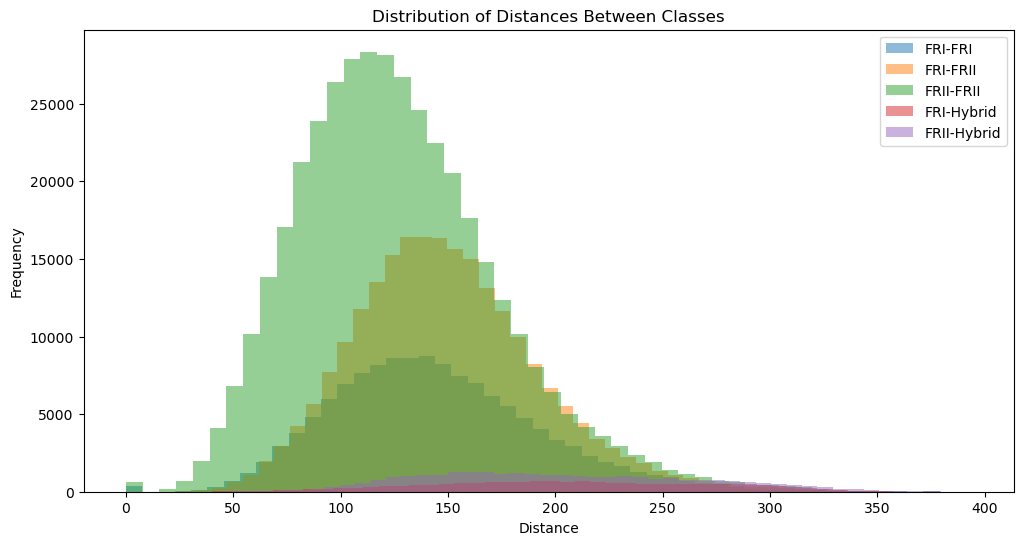

In [45]:
#Show the distribution of distance between FRI-FRII pairs, FRI-hybrid pairs, and FRII-hybrid pairs
from scipy.spatial.distance import pdist, squareform
# Compute pairwise distances
distances = squareform(pdist(test_proj[combined_mask]))
# Get indices for each class
indices_fri = np.where(test_labels_single == 0)[0]
indices_frii = np.where(test_labels_single == 1)[0]
indices_hybrid = np.where(test_labels_single == 2)[0]
# Compute distances for each pair type
dist_fri_fri = distances[np.ix_(indices_fri, indices_fri)].flatten()
dist_fri_frii = distances[np.ix_(indices_fri, indices_frii)].flatten()
dist_frii_frii = distances[np.ix_(indices_frii, indices_frii)].flatten()
dist_fri_hybrid = distances[np.ix_(indices_fri, indices_hybrid)].flatten()
dist_frii_hybrid = distances[np.ix_(indices_frii, indices_hybrid)].flatten()
# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(dist_fri_fri, bins=50, alpha=0.5, label='FRI-FRI')
plt.hist(dist_fri_frii, bins=50, alpha=0.5, label='FRI-FRII')
plt.hist(dist_frii_frii, bins=50, alpha=0.5, label='FRII-FRII')
plt.hist(dist_fri_hybrid, bins=50, alpha=0.5, label='FRI-Hybrid')
plt.hist(dist_frii_hybrid, bins=50, alpha=0.5, label='FRII-Hybrid')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Distances Between Classes')
plt.legend()
plt.show()


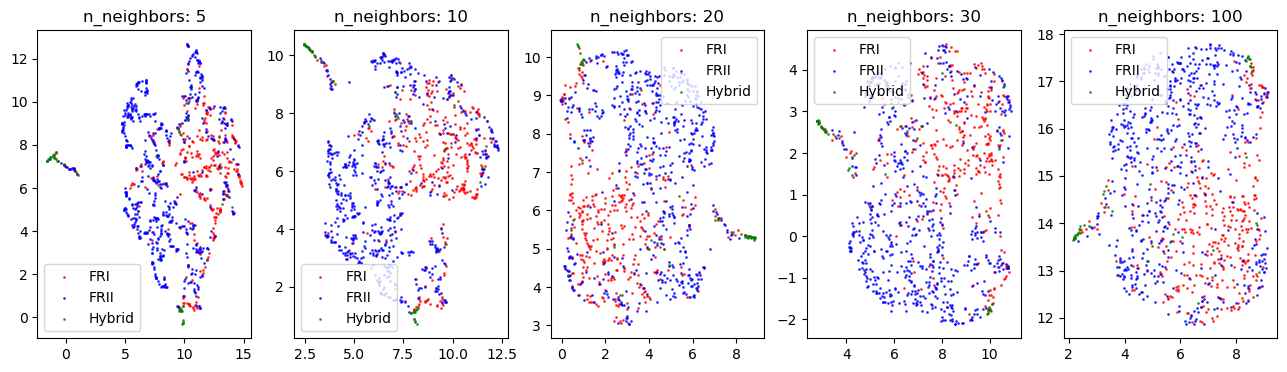

In [46]:
#test umap-learn by varying the n_neighbors and min_dist parameters

def UMAP_embedding(embeddings, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric='euclidean'
    )
    embedding_2d = reducer.fit_transform(embeddings)
    return embedding_2d

# Make 5 subplots varying n_neighbors

n_neighbors_values = [5, 10, 20, 30, 100]

plt.figure(figsize=(16, 4))
for i, n_neighbors in enumerate(n_neighbors_values):
    embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=n_neighbors, min_dist=0.1)
    plt.subplot(1, 5, i + 1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'n_neighbors: {n_neighbors}')
plt.show()

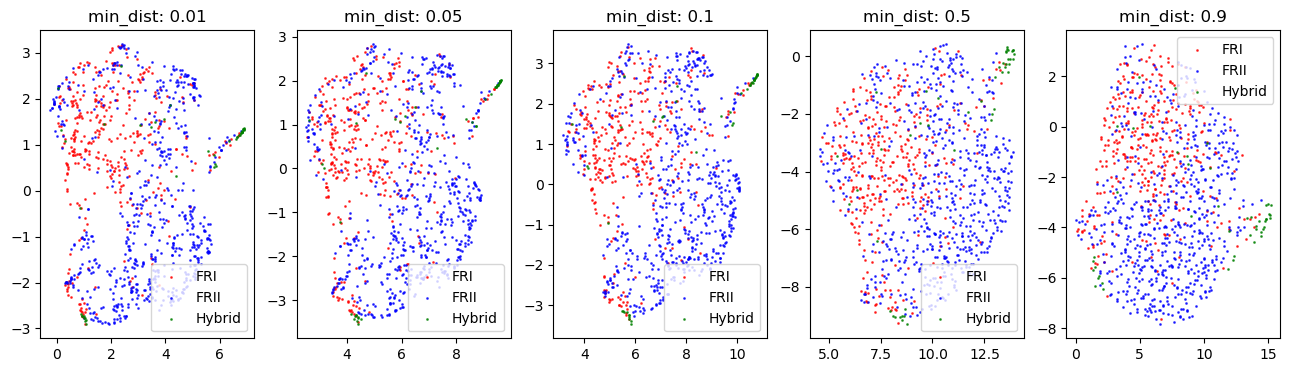

In [47]:
# Make 5 subplots varying min_dist
min_dist_values = [0.01, 0.05, 0.1, 0.5, 0.9]
plt.figure(figsize=(16, 4))
for i, min_dist in enumerate(min_dist_values):
    embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=50, min_dist=min_dist)
    plt.subplot(1, 5, i + 1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'min_dist: {min_dist}')
plt.show()

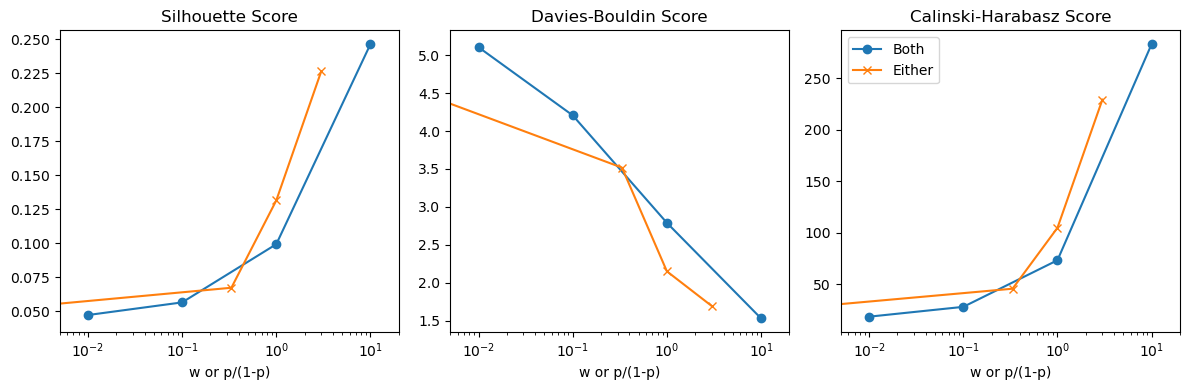

In [58]:
cases_both = [0.01, 0.1, 1, 10]
cases_either = [0, 0.25, 0.5, 0.75]

# compute silhouette, davies bouldin, calinski harabasz for each case, make a plot as a function of the case values
silhouette_scores = np.zeros((2, 4))
davies_bouldin_scores = np.zeros((2, 4))
calinski_harabasz_scores = np.zeros((2, 4))
for i, case in enumerate(cases_both):
    tmp_test_proj = np.load(data_path%f"run_both_w{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_both_w{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[0, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[0, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[0, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

for i, case in enumerate(cases_either):
    tmp_test_proj = np.load(data_path%f"run_either_p{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_either_p{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[1, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[1, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[1, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

cases_both = np.array(cases_both)
cases_either = np.array(cases_either)
# Plot the scores
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(cases_both, silhouette_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, silhouette_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Silhouette Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 2)
plt.plot(cases_both, davies_bouldin_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, davies_bouldin_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Davies-Bouldin Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 3)
plt.plot(cases_both, calinski_harabasz_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, calinski_harabasz_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Calinski-Harabasz Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.legend()
plt.tight_layout()
plt.show()

(1142,) (5312,)


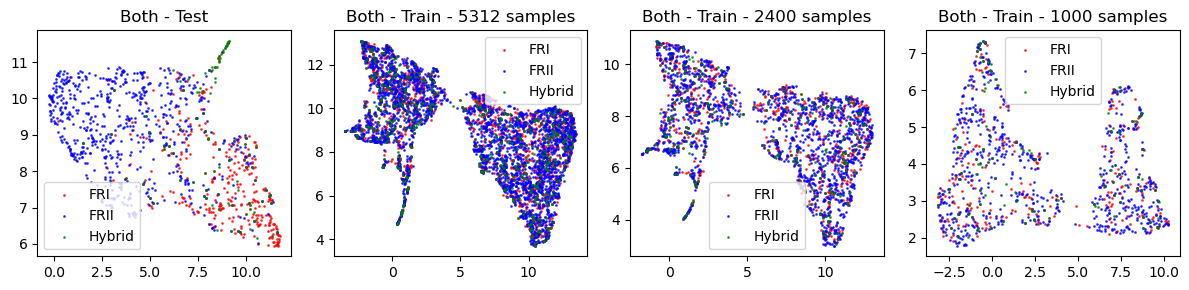

In [68]:
# Now let's do the UMAPs for the best cases of both and either. We take n_neighbors=30 and min_dist=0.1.
# We do on the train and on the test. We vary the number of samples on train from all to the same number as test.
n_neighbors = 30
min_dist = 0.1
#First for both, best is with w=10
test_proj_both = np.load(data_path%f"run_both_w10" + "test_projections.npy")
test_labels_both = np.load(data_path%f"run_both_w10" + "test_labels.npy")
train_proj_both = np.load(data_path%f"run_both_w10" + "train_projections.npy")
train_labels_both = np.load(data_path%f"run_both_w10" + "train_labels.npy")
#compute the combined mask for train and test
mask_fri_test = (test_labels_both[:,0] == 1) & (test_labels_both[:,1] == 0) & (test_labels_both[:,2] == 0)
mask_frii_test = (test_labels_both[:,0] == 0 ) & (test_labels_both[:,1] == 1) & (test_labels_both[:,2] == 0)
mask_hybrid_test = test_labels_both[:, 2] == 1 #OK
mask_fri_train = (train_labels_both[:,0] == 1) & (train_labels_both[:,1] == 0) & (train_labels_both[:,2] == 0)
mask_frii_train = (train_labels_both[:,0] == 0) & (train_labels_both[:,1] == 1) & (train_labels_both[:,2] == 0)
mask_hybrid_train = train_labels_both[:, 2] == 1 #OK
combined_mask_test = mask_fri_test | mask_frii_test | mask_hybrid_test
combined_mask_train = mask_fri_train | mask_frii_train | mask_hybrid_train
print(combined_mask_test.shape, combined_mask_train.shape)
#run Umap on test and train
embedding_2d_test_both = UMAP_embedding(test_proj_both[combined_mask_test], n_neighbors=n_neighbors, min_dist=min_dist)
embedding_2d_train_both = UMAP_embedding(train_proj_both[combined_mask_train], n_neighbors=n_neighbors, min_dist=min_dist)
#plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
plt.legend()
plt.title(f'Both - Test')
# Now do it for train, full sample, 2400 random samples and 1200 random samples
for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
    if n_samples < combined_mask_train.shape[0]:
        indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
    else:
        indices = np.where(combined_mask_train)[0]
    embedding_2d_train_both_sample = UMAP_embedding(train_proj_both[indices], n_neighbors=n_neighbors, min_dist=min_dist)
    plt.subplot(1, 4, i + 2)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'Both - Train - {n_samples} samples')
plt.tight_layout()
plt.show()

In [61]:
print(np.where(combined_mask_train)[0])
print(combined_mask_train)

[   0    1    2 ... 5309 5310 5311]
[ True  True  True ...  True  True  True]


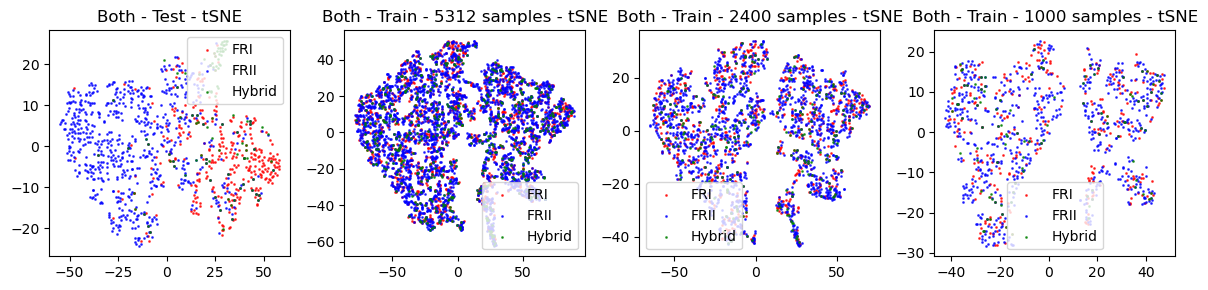

In [ ]:
#try tSNE on the same data: sklearn.manifold.TSNE
from sklearn.manifold import TSNE
embedding_2d_test_both_tsne = TSNE(n_components=2, perplexity=30).fit_transform(test_proj_both[combined_mask_test])
embedding_2d_train_both_tsne = TSNE(n_components=2, perplexity=30).fit_transform(train_proj_both[combined_mask_train])
#plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
scatter = plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
plt.legend()
plt.title(f'Both - Test - tSNE')
# Now do it for train, full sample, 2400 random samples and 1200 random samples
for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
    if n_samples < combined_mask_train.shape[0]:
        indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
    else:
        indices = np.where(combined_mask_train)[0]
    embedding_2d_train_both_sample_tsne = TSNE(n_components=2, perplexity=30).fit_transform(train_proj_both[indices])
    plt.subplot(1, 4, i + 2)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    scatter = plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    #plt.legend()
    plt.title(f'Both - Train - {n_samples} samples - tSNE')
plt.tight_layout()
plt.show()